# TrendInCharts v1.2 — Interactive Visualization

## Purpose
Visualize Yahoo Consensus trends over time for individual tickers using interactive Plotly charts.

## Input
- All `*_YahooConsensus.csv` files in the folder
- Single ticker specified in config (change `TICKER` variable)

## Output
7 interactive Plotly charts displayed inline:

1. **Target Price Trend** — TP(Min/Avg/Max) + Current Price overlay
2. **Analyst Count Trend** — Coverage over time
3. **Target Price Dispersion** — Analyst agreement measure
4. **Revenue Consensus Trend** — Y1 & Y2 estimates
5. **EPS Consensus Trend** — Y1 & Y2 estimates
6. **Revenue Growth Consensus** — YoY growth expectations
7. **EPS Growth Consensus** — YoY growth expectations

## Dash Pattern Legend
- **Solid line** = Avg (most important)
- **Small dashes (▬ ▬ ▬)** = Min (lower bound)
- **Wide dashes (▬▬ ▬▬)** = Max (upper bound)

## Usage
1. Set `TICKER` variable in Cell 1
2. Run all cells
3. Change ticker and re-run for different stock

In [70]:
import pandas as pd
import glob
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ================= CONFIG =================
FOLDER = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus"
TICKER1 = "VENUSPIPES"
TICKER2 = "ANUP"
TICKER3 = "ACMESOLAR"
TICKER4 = "EMMVEE"
TICKER5 = "HDFCAMC"
TICKER6 = "HDFCBANK"

TICKER = TICKER4    # ← CHANGE THIS

# ================= LOAD DATA =================
files = sorted(glob.glob(f"{FOLDER}\\*_YahooConsensus.csv"))
if not files:
    raise FileNotFoundError(f"No CSV files found in {FOLDER}")

df_all = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df_all["Date"] = pd.to_datetime(df_all["Date"])
df_t = df_all[df_all["YAHOO Ticker"] == TICKER].copy()

if df_t.empty:
    raise ValueError(f"No data for {TICKER}")

fy_sorted = sorted(df_t["FIN Yr"].dropna().unique())
if len(fy_sorted) < 2:
    raise ValueError(f"{TICKER} needs at least 2 FIN Yr")

Y1, Y2 = fy_sorted[0], fy_sorted[1]

print(f"Loaded {TICKER}")
print(f"Date range: {df_t['Date'].min().date()} to {df_t['Date'].max().date()}")
print(f"FIN Years: Y1={Y1}, Y2={Y2}\n")

Loaded EMMVEE
Date range: 2026-02-06 to 2026-04-10
FIN Years: Y1=FY26, Y2=FY27



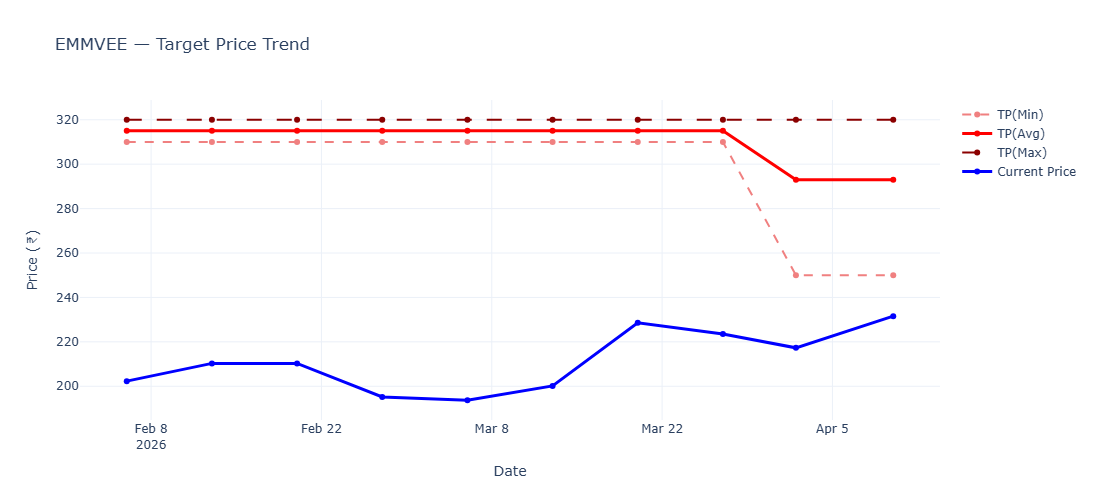

In [71]:
# ================= CHART 1: TARGET PRICE + CURRENT PRICE =================
df_tp = df_t.sort_values("FIN Yr").groupby("Date", as_index=False).agg({
    "TP(Min)": "first", "TP(Avg)": "first", "TP(Max)": "first",
    "Current Price": "first", "#Count": "first"
})

fig = make_subplots(specs=[[{"secondary_y": False}]])

fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["TP(Min)"], name="TP(Min)",
    mode="lines+markers", line=dict(color="lightcoral", width=2, dash="dash"),
    hovertemplate="<b>TP(Min)</b><br>%{x|%Y-%m-%d}<br>₹%{y:.0f}<extra></extra>"
))
fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["TP(Avg)"], name="TP(Avg)",
    mode="lines+markers", line=dict(color="red", width=3),
    hovertemplate="<b>TP(Avg)</b><br>%{x|%Y-%m-%d}<br>₹%{y:.0f}<extra></extra>"
))
fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["TP(Max)"], name="TP(Max)",
    mode="lines+markers", line=dict(color="darkred", width=2, dash="longdash"),
    hovertemplate="<b>TP(Max)</b><br>%{x|%Y-%m-%d}<br>₹%{y:.0f}<extra></extra>"
))
fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["Current Price"], name="Current Price",
    mode="lines+markers", line=dict(color="blue", width=3), marker=dict(size=6),
    hovertemplate="<b>Current Price</b><br>%{x|%Y-%m-%d}<br>₹%{y:.0f}<extra></extra>"
))

fig.update_layout(
    title=f"{TICKER} — Target Price Trend",
    xaxis_title="Date", yaxis_title="Price (₹)",
    hovermode="x unified", height=500, template="plotly_white"
)
fig.show()

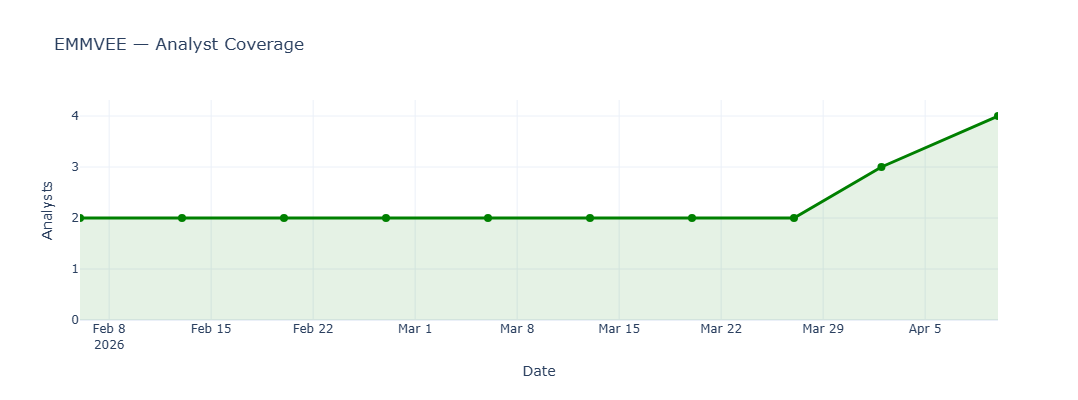

Coverage: 2-4, Latest: 4


In [72]:
# ================= CHART 2: ANALYST COUNT =================
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["#Count"], name="Analyst Count",
    mode="lines+markers", line=dict(color="green", width=3),
    marker=dict(size=8), fill="tozeroy", fillcolor="rgba(0,128,0,0.1)",
    hovertemplate="<b>Coverage</b><br>%{x|%Y-%m-%d}<br>%{y} analysts<extra></extra>"
))
fig.update_layout(
    title=f"{TICKER} — Analyst Coverage",
    xaxis_title="Date", yaxis_title="Analysts",
    hovermode="x unified", height=400, template="plotly_white"
)
fig.show()
print(f"Coverage: {df_tp['#Count'].min():.0f}-{df_tp['#Count'].max():.0f}, Latest: {df_tp['#Count'].iloc[-1]:.0f}")

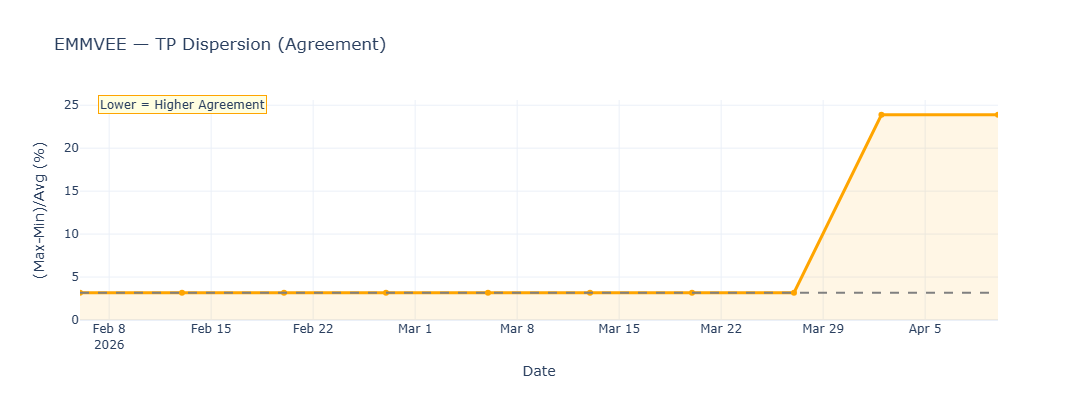

Dispersion: 3.2%-23.9%, Latest: 23.9%


In [73]:
# ================= CHART 3: DISPERSION =================
df_tp["TP_Disp_Pct"] = ((df_tp["TP(Max)"] - df_tp["TP(Min)"]) / df_tp["TP(Avg)"]) * 100
median_disp = df_tp["TP_Disp_Pct"].median()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_tp["Date"], y=df_tp["TP_Disp_Pct"], name="Dispersion",
    mode="lines+markers", line=dict(color="orange", width=3),
    fill="tozeroy", fillcolor="rgba(255,165,0,0.1)",
    hovertemplate="<b>Dispersion</b><br>%{x|%Y-%m-%d}<br>%{y:.1f}%<extra></extra>"
))
fig.add_hline(y=median_disp, line_dash="dash", line_color="gray",
              annotation_text=f"Median: {median_disp:.1f}%", annotation_position="right")
fig.update_layout(
    title=f"{TICKER} — TP Dispersion (Agreement)",
    xaxis_title="Date", yaxis_title="(Max-Min)/Avg (%)",
    hovermode="x unified", height=400, template="plotly_white",
    annotations=[dict(text="Lower = Higher Agreement", xref="paper", yref="paper",
                      x=0.02, y=0.98, showarrow=False, bgcolor="lightyellow",
                      bordercolor="orange", borderwidth=1)]
)
fig.show()
print(f"Dispersion: {df_tp['TP_Disp_Pct'].min():.1f}%-{df_tp['TP_Disp_Pct'].max():.1f}%, Latest: {df_tp['TP_Disp_Pct'].iloc[-1]:.1f}%")

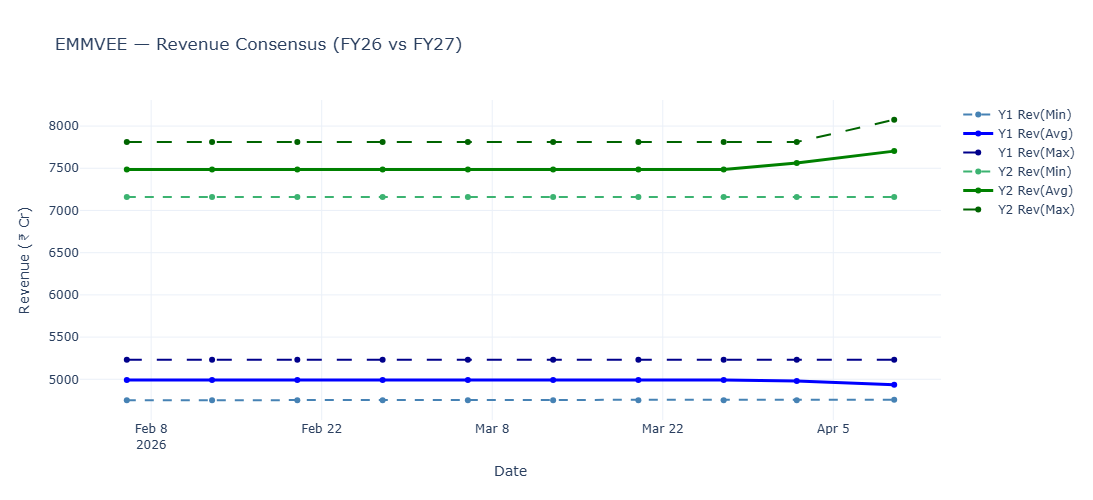

In [74]:
# ================= CHART 4: REVENUE CONSENSUS =================
df_rev = df_t[df_t["FIN Yr"].isin([Y1, Y2])].copy()
fig = go.Figure()

for fy in [Y1, Y2]:
    df_fy = df_rev[df_rev["FIN Yr"] == fy]
    lbl = "Y1" if fy == Y1 else "Y2"
    c_min, c_avg, c_max = ("steelblue", "blue", "darkblue") if fy == Y1 else ("mediumseagreen", "green", "darkgreen")
    
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["Rev.(Min)"], name=f"{lbl} Rev(Min)",
        mode="lines+markers", line=dict(color=c_min, width=2, dash="dash"),
        hovertemplate=f"<b>{lbl} Rev(Min)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.0f}} Cr<extra></extra>"))
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["Rev.(Avg)"], name=f"{lbl} Rev(Avg)",
        mode="lines+markers", line=dict(color=c_avg, width=3),
        hovertemplate=f"<b>{lbl} Rev(Avg)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.0f}} Cr<extra></extra>"))
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["Rev.(Max)"], name=f"{lbl} Rev(Max)",
        mode="lines+markers", line=dict(color=c_max, width=2, dash="longdash"),
        hovertemplate=f"<b>{lbl} Rev(Max)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.0f}} Cr<extra></extra>"))

fig.update_layout(title=f"{TICKER} — Revenue Consensus ({Y1} vs {Y2})",
    xaxis_title="Date", yaxis_title="Revenue (₹ Cr)",
    hovermode="x unified", height=500, template="plotly_white")
fig.show()

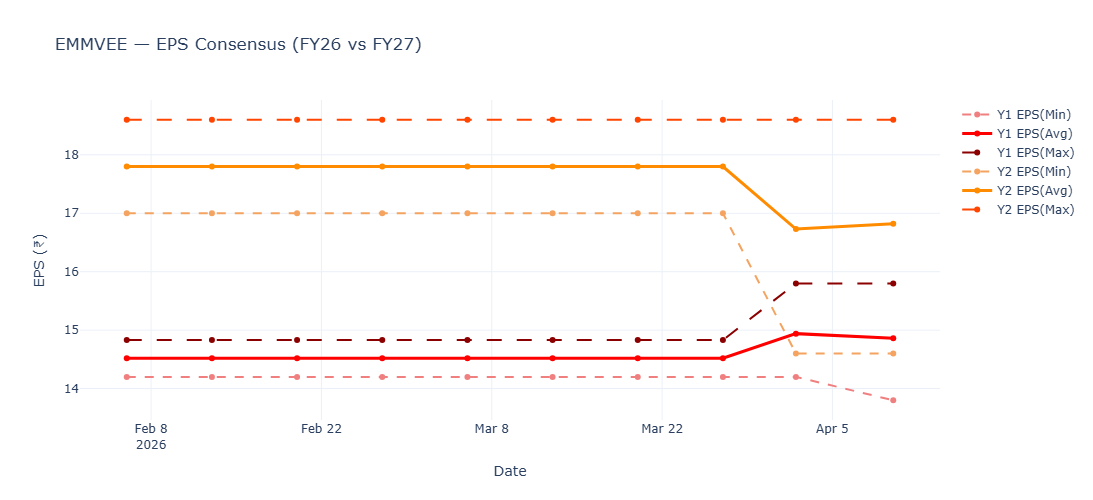

In [75]:
# ================= CHART 5: EPS CONSENSUS =================
df_eps = df_t[df_t["FIN Yr"].isin([Y1, Y2])].copy()
fig = go.Figure()

for fy in [Y1, Y2]:
    df_fy = df_eps[df_eps["FIN Yr"] == fy]
    lbl = "Y1" if fy == Y1 else "Y2"
    c_min, c_avg, c_max = ("lightcoral", "red", "darkred") if fy == Y1 else ("sandybrown", "darkorange", "orangered")
    
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["EPS(Min)"], name=f"{lbl} EPS(Min)",
        mode="lines+markers", line=dict(color=c_min, width=2, dash="dash"),
        hovertemplate=f"<b>{lbl} EPS(Min)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.2f}}<extra></extra>"))
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["EPS(Avg)"], name=f"{lbl} EPS(Avg)",
        mode="lines+markers", line=dict(color=c_avg, width=3),
        hovertemplate=f"<b>{lbl} EPS(Avg)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.2f}}<extra></extra>"))
    fig.add_trace(go.Scatter(x=df_fy["Date"], y=df_fy["EPS(Max)"], name=f"{lbl} EPS(Max)",
        mode="lines+markers", line=dict(color=c_max, width=2, dash="longdash"),
        hovertemplate=f"<b>{lbl} EPS(Max)</b><br>%{{x|%Y-%m-%d}}<br>₹%{{y:.2f}}<extra></extra>"))

fig.update_layout(title=f"{TICKER} — EPS Consensus ({Y1} vs {Y2})",
    xaxis_title="Date", yaxis_title="EPS (₹)",
    hovermode="x unified", height=500, template="plotly_white")
fig.show()

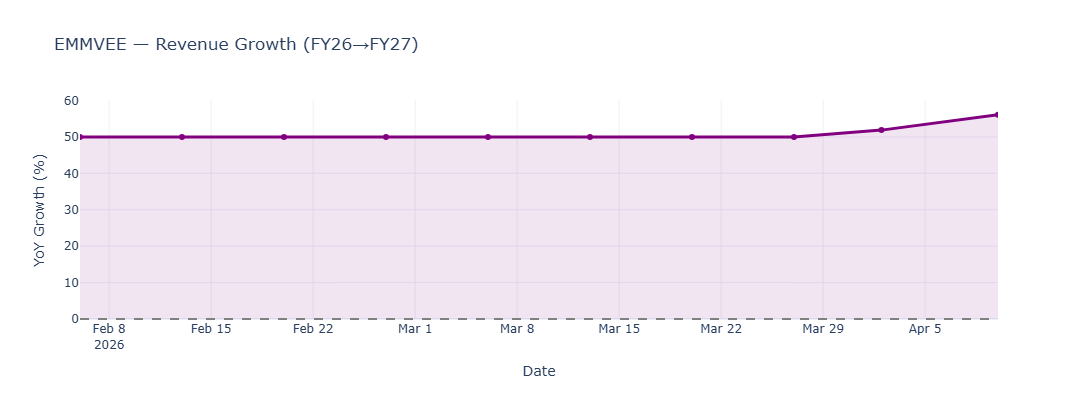

Rev growth: 50.0%-56.1%, Latest: 56.1%


In [76]:
# ================= CHART 6: REVENUE GROWTH =================
df_rg = df_t[df_t["FIN Yr"].isin([Y1, Y2])].copy()
df_y1 = df_rg[df_rg["FIN Yr"] == Y1][["Date", "Rev.(Avg)"]].rename(columns={"Rev.(Avg)": "Rev_Y1"})
df_y2 = df_rg[df_rg["FIN Yr"] == Y2][["Date", "Rev.(Avg)"]].rename(columns={"Rev.(Avg)": "Rev_Y2"})
df_growth = df_y1.merge(df_y2, on="Date", how="inner")
df_growth["Rev_Growth_Pct"] = ((df_growth["Rev_Y2"] / df_growth["Rev_Y1"]) - 1) * 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_growth["Date"], y=df_growth["Rev_Growth_Pct"],
    name="Rev Growth Y1→Y2", mode="lines+markers", line=dict(color="purple", width=3),
    fill="tozeroy", fillcolor="rgba(128,0,128,0.1)",
    hovertemplate="<b>YoY Rev Growth</b><br>%{x|%Y-%m-%d}<br>%{y:.1f}%<extra></extra>"))
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(title=f"{TICKER} — Revenue Growth ({Y1}→{Y2})",
    xaxis_title="Date", yaxis_title="YoY Growth (%)",
    hovermode="x unified", height=400, template="plotly_white")
fig.show()
print(f"Rev growth: {df_growth['Rev_Growth_Pct'].min():.1f}%-{df_growth['Rev_Growth_Pct'].max():.1f}%, Latest: {df_growth['Rev_Growth_Pct'].iloc[-1]:.1f}%")

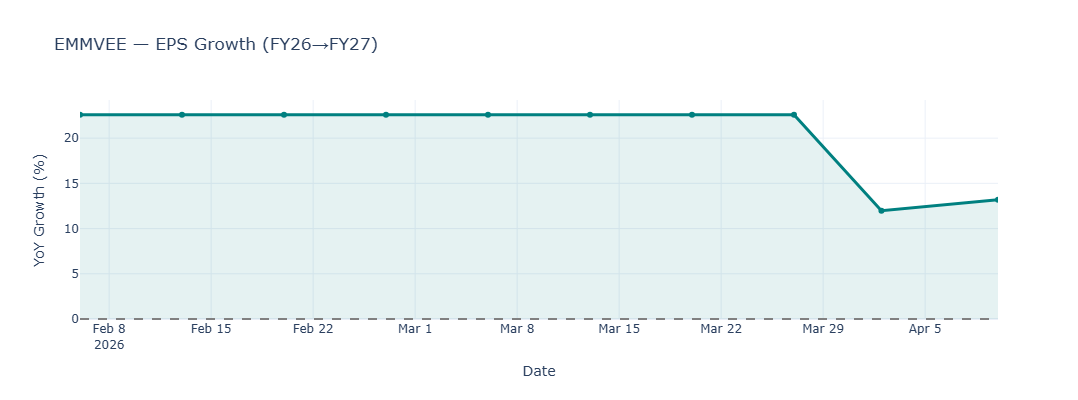

EPS growth: 12.0%-22.6%, Latest: 13.2%

✅ All 7 charts generated for EMMVEE!


In [77]:
# ================= CHART 7: EPS GROWTH =================
df_epsg = df_t[df_t["FIN Yr"].isin([Y1, Y2])].copy()
df_y1_eps = df_epsg[df_epsg["FIN Yr"] == Y1][["Date", "EPS(Avg)"]].rename(columns={"EPS(Avg)": "EPS_Y1"})
df_y2_eps = df_epsg[df_epsg["FIN Yr"] == Y2][["Date", "EPS(Avg)"]].rename(columns={"EPS(Avg)": "EPS_Y2"})
df_eps_growth = df_y1_eps.merge(df_y2_eps, on="Date", how="inner")
df_eps_growth["EPS_Growth_Pct"] = ((df_eps_growth["EPS_Y2"] / df_eps_growth["EPS_Y1"]) - 1) * 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_eps_growth["Date"], y=df_eps_growth["EPS_Growth_Pct"],
    name="EPS Growth Y1→Y2", mode="lines+markers", line=dict(color="teal", width=3),
    fill="tozeroy", fillcolor="rgba(0,128,128,0.1)",
    hovertemplate="<b>YoY EPS Growth</b><br>%{x|%Y-%m-%d}<br>%{y:.1f}%<extra></extra>"))
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(title=f"{TICKER} — EPS Growth ({Y1}→{Y2})",
    xaxis_title="Date", yaxis_title="YoY Growth (%)",
    hovermode="x unified", height=400, template="plotly_white")
fig.show()
print(f"EPS growth: {df_eps_growth['EPS_Growth_Pct'].min():.1f}%-{df_eps_growth['EPS_Growth_Pct'].max():.1f}%, Latest: {df_eps_growth['EPS_Growth_Pct'].iloc[-1]:.1f}%")
print(f"\n✅ All 7 charts generated for {TICKER}!")